<a href="https://colab.research.google.com/github/Gnissan-BIA/Assignments/blob/main/Assignment_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Titanic Dataset Exploratory Data Analysis

In [4]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Task 1: Load the Titanic dataset
# Load the Titanic dataset from the following URL
import pandas as pd

# URL of dataset
#url = "https://web.stanford.edu/class/archive/cs/cs109/cs109.1166/stuff/titanic.csv"

# Load dataset into DataFrame
df = pd.read_csv("/content/Titanic/Titanic-Dataset.csv")

# Task 2: Inspect the data

In [5]:
# Display the first 5 rows of the dataset
print("The  first 5 rows of the dataset:")
print(df.head())
print()

# Display the last 5 rows of the dataset
print("The last 5 rows of the dataset:")
print(df.tail())
print()

#Display the data types of each column
print("The data types:")
df.dtypes
print()

# Display summary statistics of the numerical columns
print("Statistical summary:")
print(df.describe())
print()

The  first 5 rows of the dataset:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            3

# Task 3: Clean and preprocess the data

In [6]:
# Create a new categorical feature 'PclassCategory' from 'Pclass'
df['PclassCategory'] = df['Pclass'].map({1: 'Upper', 2: 'Middle', 3: 'Lower'})
print(df.head())
print()

# Create a new categorical feature 'CabinCategory' from 'Cabin'
df['CabinCategory'] = df['Cabin'].apply(
    lambda x: x[0] if pd.notnull(x) else 'Unknown'
)
print()

# Handle missing values in the 'Age' column (use mean age)
print("Number of null values in Age:", df['Age'].isnull().sum())
df['Age'] = df['Age'].fillna(df['Age'].mean())

# TODO: Create a 'Family' feature by combining 'SibSp' and 'Parch'

df['Family'] = df['SibSp'] + df['Parch']
print("\n'Family' feature created successfully.")
print()

print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked PclassCategory  
0      0         A/5 21171   7.2500   NaN        S          Lower  
1      0          PC 17599  71.2833   C85        C          Upper  
2      0  STON/O2. 3101282   7.9250   NaN        S          Lower  
3      0            113803  53.1000  C123       

# Task 4: Identify specific data points

In [7]:
# Find passengers with the highest fare
max_fare = df['Fare'].max()
highest_fare_passengers = df[df['Fare'] == max_fare]

print("\nPassengers with the highest fare:")
print(highest_fare_passengers[['Name', 'Fare']])
print()

# Find passengers with the largest family size
max_family = df['Family'].max()
largest_family_passengers = df[df['Family'] == max_family]

print("\nPassengers with the largest family size:")
print(largest_family_passengers[['Name', 'Family']])


Passengers with the highest fare:
                                   Name      Fare
258                    Ward, Miss. Anna  512.3292
679  Cardeza, Mr. Thomas Drake Martinez  512.3292
737              Lesurer, Mr. Gustave J  512.3292


Passengers with the largest family size:
                                  Name  Family
159         Sage, Master. Thomas Henry      10
180       Sage, Miss. Constance Gladys      10
201                Sage, Mr. Frederick      10
324           Sage, Mr. George John Jr      10
792            Sage, Miss. Stella Anna      10
846           Sage, Mr. Douglas Bullen      10
863  Sage, Miss. Dorothy Edith "Dolly"      10


# Task 5: Demonstrate Pandas Series and DataFrame functionalities

In [8]:
# Create a Pandas Series of passenger names
names_series = df['Name']
print("Names Series:")
print(names_series.head())
print()

# Create a DataFrame of passenger names and ages
names_ages_df = df[['Name', 'Age']]
print("\nNames and Ages DataFrame:")
print(names_ages_df.head())
print()

# Slice the DataFrame to show only passengers older than 50
older_passengers = df[df['Age'] > 50]
print("\nPassengers older than 50:")
print(older_passengers[['Name', 'Age']].head())

Names Series:
0                              Braund, Mr. Owen Harris
1    Cumings, Mrs. John Bradley (Florence Briggs Th...
2                               Heikkinen, Miss. Laina
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                             Allen, Mr. William Henry
Name: Name, dtype: object


Names and Ages DataFrame:
                                                Name   Age
0                            Braund, Mr. Owen Harris  22.0
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  38.0
2                             Heikkinen, Miss. Laina  26.0
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  35.0
4                           Allen, Mr. William Henry  35.0


Passengers older than 50:
                                Name   Age
6            McCarthy, Mr. Timothy J  54.0
11          Bonnell, Miss. Elizabeth  58.0
15  Hewlett, Mrs. (Mary D Kingcome)   55.0
33             Wheadon, Mr. Edward H  66.0
54    Ostby, Mr. Engelhart Cornelius  65.0


# Task 7: Visualizations

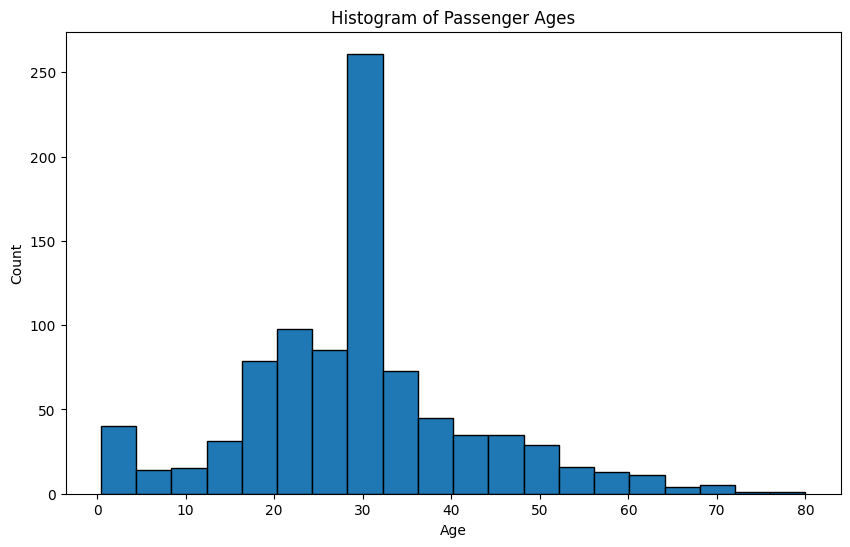

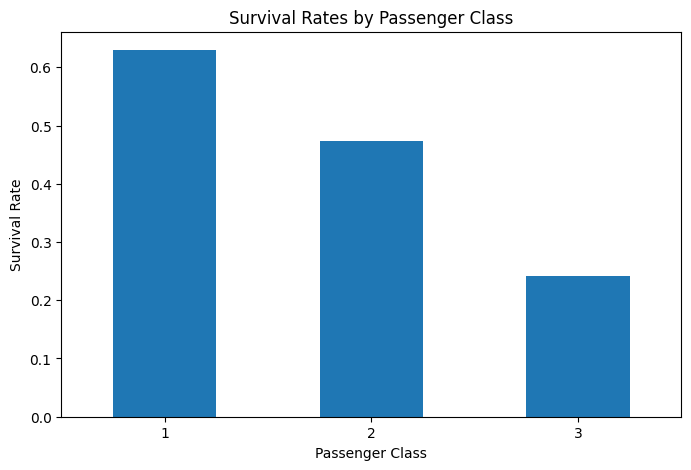

Survival rates by passenger class:
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


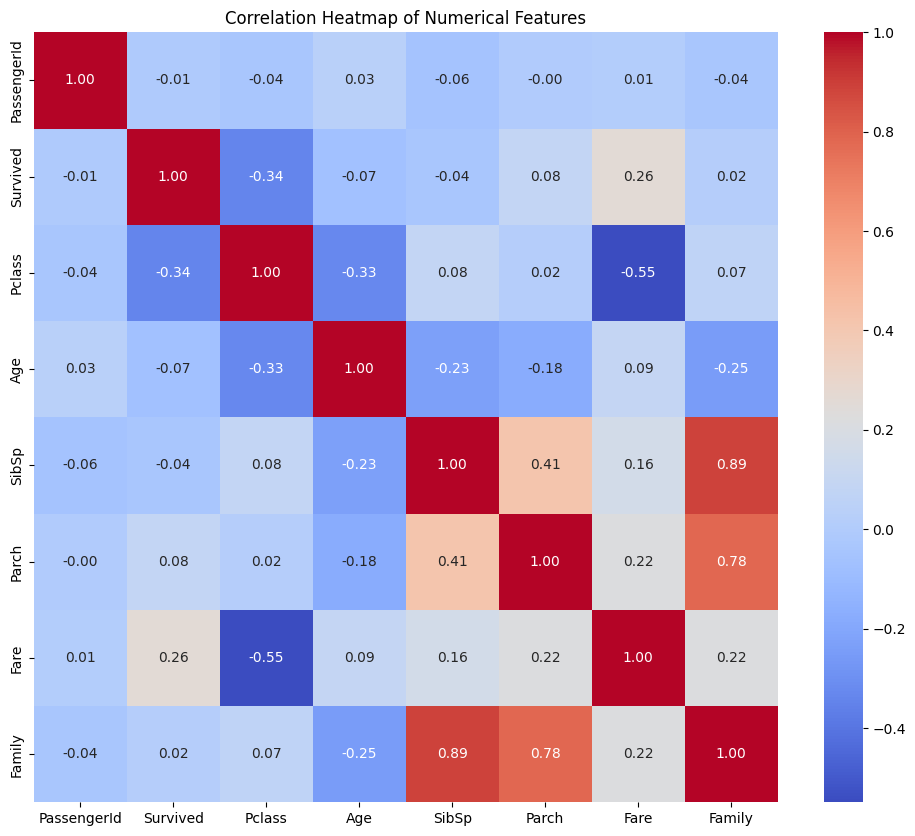

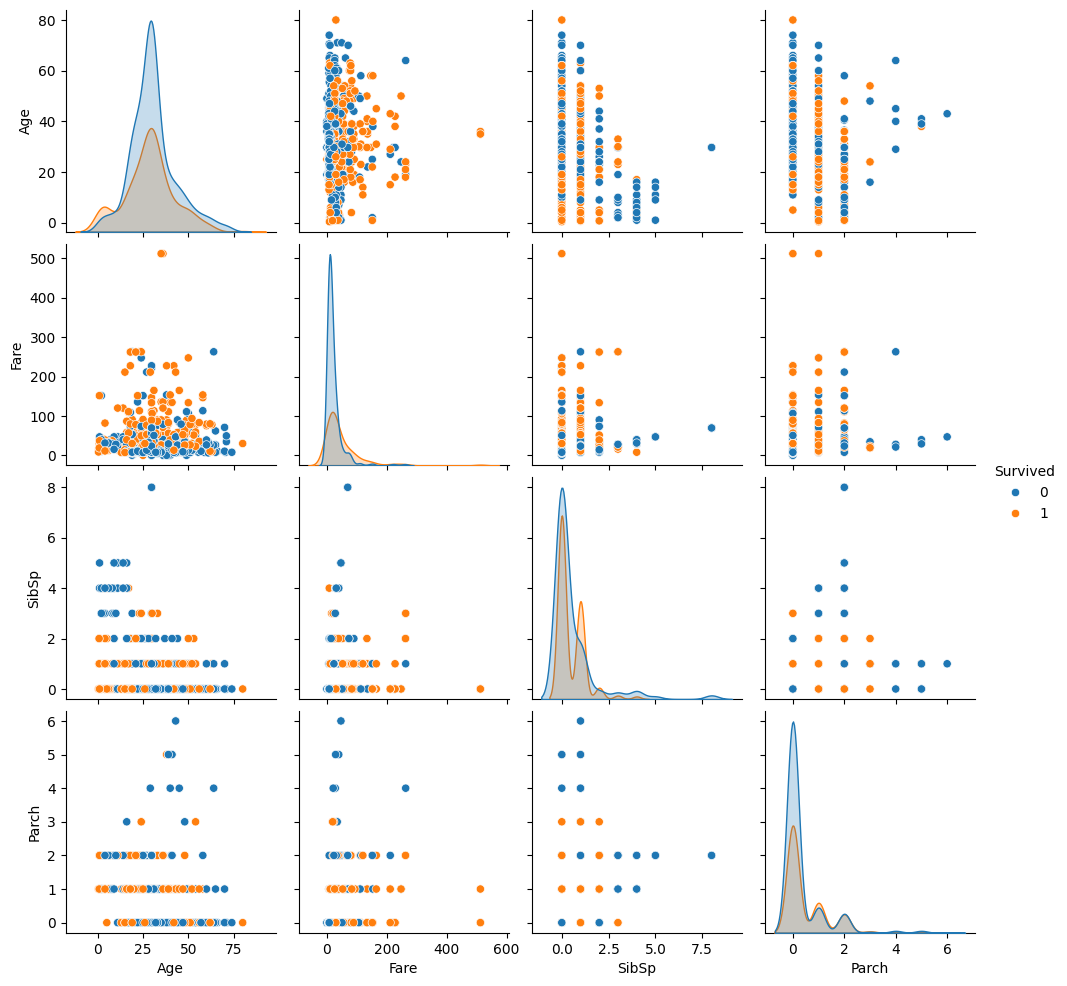

In [9]:
# Create a histogram of passenger ages

plt.figure(figsize=(10, 6))
plt.hist(df['Age'].dropna(), bins=20, edgecolor='black')
plt.title('Histogram of Passenger Ages')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

# Create a bar plot of survival rates by passenger class

survival_by_class = df.groupby('Pclass')['Survived'].mean()

plt.figure(figsize=(8, 5))
survival_by_class.plot(kind='bar')
plt.title('Survival Rates by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.xticks(rotation=0)
plt.show()

print("Survival rates by passenger class:")
print(survival_by_class)

# Create a heatmap of correlation between numerical features

numerical_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(12, 10))
sns.heatmap(numerical_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

# Create a pair plot of 'Age', 'Fare', 'SibSp', and 'Parch', colored by 'Survived'

selected_cols = ['Age', 'Fare', 'SibSp', 'Parch', 'Survived']
pairplot_df = df[selected_cols].dropna()
sns.pairplot(pairplot_df, hue='Survived')
plt.show()

# Task 9: Analyze age distribution

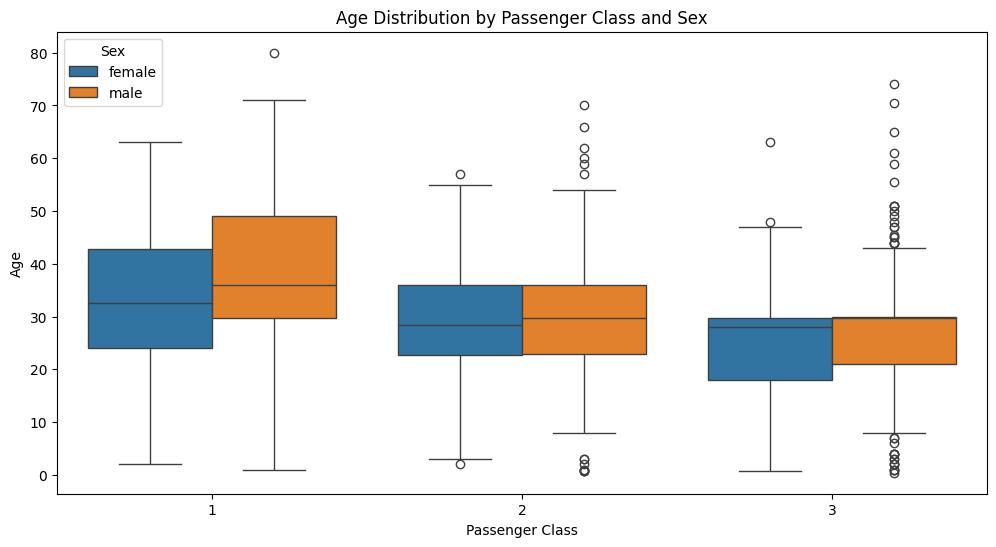

In [10]:
# Create a box plot of age distribution by passenger class and sex

selected_cols = ['Age', 'Pclass', 'Sex']
plt.figure(figsize=(12, 6))

# Box plot: Age distribution by Pclass and Sex
sns.boxplot(x='Pclass', y='Age', hue='Sex', data=df)

plt.title('Age Distribution by Passenger Class and Sex')
plt.xlabel('Passenger Class')
plt.ylabel('Age')
plt.show()

# Task 10: Analyze fare distribution

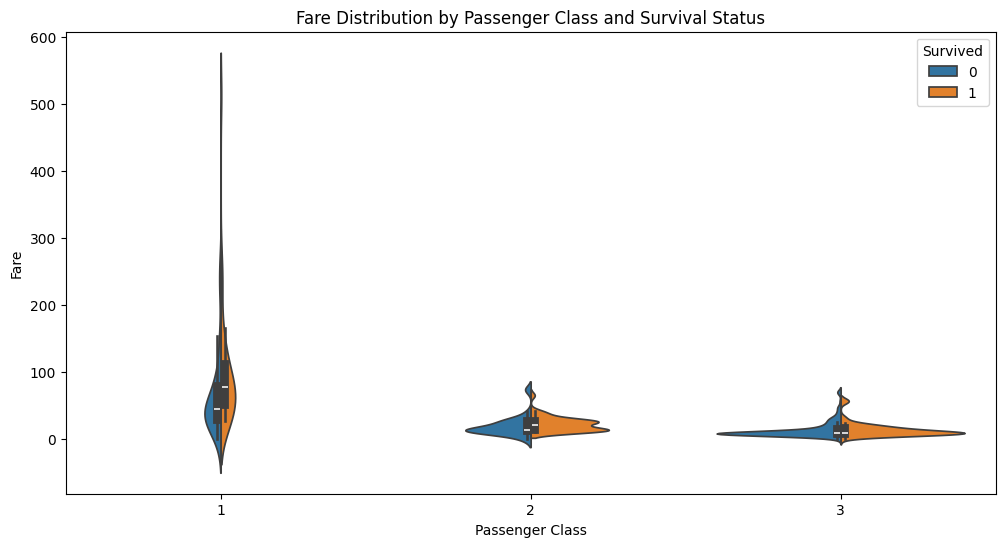

In [11]:
# Create a violin plot of fare distribution by passenger class and survival status

selected_cols = ['Fare', 'Pclass', 'Survived']
plt.figure(figsize=(12, 6))

# Violin plot: Fare distribution by Pclass and Survival
sns.violinplot(x='Pclass', y='Fare', hue='Survived', data=df, split=True)
plt.title('Fare Distribution by Passenger Class and Survival Status')
plt.xlabel('Passenger Class')
plt.ylabel('Fare')
plt.show()